In [18]:
import pathlib
import typing

import matplotlib.pyplot as plt
import rasterio
import torch
import torch.utils.data
import torchgeo.datasets
import torchgeo.samplers
import torchgeo.transforms

# Data Loading
This notebook uses the [Earth Surface Water Dataset](https://zenodo.org/records/5205674), a collection of six-band Sentinel 2 images accompanied by water body masks.

| Data band | sentinel band | res | wavelength | desc                             |
|-----------|---------------|-----|------------|----------------------------------|
| 1         | 2             | 10  | 490        | B                                |
| 2         | 3             | 10  | 560        | G                                |
| 3         | 4             | 10  | 665        | R                                |
| 4         | 8             | 10  | 842        | Visible and Near Infrared (VNIR) |
| 5         | 11            | 20  | 1610       | Short Wave Infrared (SWIR)       |
| 6         | 12            | 20  | 2190       | Short Wave Infrared (SWIR)       |

In [2]:
root = pathlib.Path('./dset-s2')

In [3]:
train_img_path = root / 'tra_scene'
train_msk_path = root / 'tra_truth'

In [4]:
# TOSELF: I could use a pattern like this to list files during the data parsing step.
train_imgs = list((root / 'tra_scene').glob('*.tif'))
train_msks = list((root / 'tra_truth').glob('*.tif'))

In [5]:
# Ensure that the images and masks are aligned lexicographically so that they can be accessed using a single, common index.
train_imgs.sort()
train_msks.sort()

# Data Exploration

In [6]:
img_idx = 0

In [7]:
img_src: rasterio.io.DatasetReader
msk_src: rasterio.io.DatasetReader
with rasterio.open(train_imgs[img_idx]) as img_src:
    img = img_src.read()
with rasterio.open(train_msks[img_idx]) as msk_src:
    msk = msk_src.read()

In [8]:
# TOSELF: The images and masks do not need to be square.
img.shape

(6, 764, 868)

In [9]:
msk.shape

(1, 764, 868)

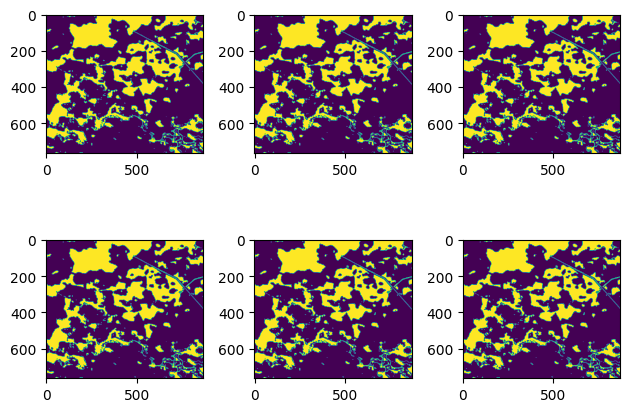

In [10]:
fig, axes = plt.subplots(2, 3)
for bnd_idx, ax in enumerate(axes.ravel()):
    # Convert the raw satellite measurements to actual pixel values.
    ax.imshow(msk[0, :, :] * 1e-5)
plt.tight_layout()

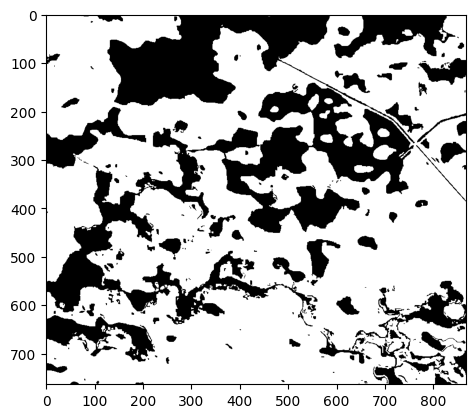

In [11]:
plt.imshow(msk[0, :, :], cmap='binary')

# Step 1 - Construct the image and mask datasets.

In [12]:
def scale_image(item: dict):
    # NOTE: A sample from the dataset is a dict in the form of:
    # {
    # "crs":
    # "bbox":
    # "image":
    # }
    # if the dataset contains masks the image key is replaced with mask
    item['image'] *= 1e-5
    return item


# TOSELF: Are the 20 m bands resampled to 10 m?
train_imgs = torchgeo.datasets.RasterDataset(train_img_path.absolute().as_posix(),
                                             # NOTE: The CRS must be specified because the images use various projections, and should thus be normalized.
                                             crs="EPSG:3395",
                                             # NOTE: The pixel size must be specified for the same reason as above.
                                             # TOSELF: Is this really required?
                                             res=10,
                                             transforms=scale_image)
train_msks = torchgeo.datasets.RasterDataset(train_msk_path.absolute().as_posix(), crs="EPSG:3395")
# Specify that the data contains masks.
train_msks.is_image = False

# Step 2 - Construct the corresponding sampler.

In [13]:
# TOSELF: Explore the various samplers.
sampler = torchgeo.samplers.RandomGeoSampler(train_imgs, size=512, length=30)

# Step 3 - Intersect the datasets.

In [14]:
# TOSELF: The images do not need to be merged with the corresponding masks.
# TOSELF: I could use a pattern like this merge rasters during the data parsing step.
train_data = train_imgs & train_msks

# Step 4 - Construct the corresponding loader.

In [15]:
# TOSELF: Explore the various loaders.
loader = torch.utils.data.DataLoader(train_data,
                                     sampler=sampler,
                                     # TOSELF: How does this parameter compare to the sampler length?
                                     batch_size=8,
                                     collate_fn=torchgeo.datasets.stack_samples)

## Data Exploration

In [16]:
# TODO: Clean up this cell.
def plot_imgs(images: typing.Iterable, axs: typing.Iterable, chnls: typing.List[int] = [2, 1, 0], bright: float = 0.1):
    for img, ax in zip(images, axs):
        arr = torch.clamp(bright * img, min=0, max=1).numpy()
        rgb = arr.transpose(1, 2, 0)[:, :, chnls]
        ax.imshow(rgb)
        ax.axis('off')


def plot_msks(masks: typing.Iterable, axs: typing.Iterable):
    for mask, ax in zip(masks, axs):
        ax.imshow(mask.squeeze().numpy(), cmap='Blues')
        ax.axis('off')


def plot_batch(batch: dict, bright: float = 3., cols: int = 4, width: int = 5, chnls: typing.List[int] = [2, 1, 0]):

    # Get the samples and the number of items in the batch
    samples = torchgeo.datasets.unbind_samples(batch.copy())

    # if batch contains images and masks, the number of images will be doubled
    n = 2 * len(samples) if ('image' in batch) and ('mask' in batch) else len(samples)

    # calculate the number of rows in the grid
    rows = n // cols + (1 if n % cols != 0 else 0)

    # create a grid
    _, axs = plt.subplots(rows, cols, figsize=(cols * width, rows * width))

    if ('image' in batch) and ('mask' in batch):
        # plot the images on the even axis
        plot_imgs(images=map(lambda x: x['image'], samples),
                  axs=axs.reshape(-1)[::2],
                  chnls=chnls,
                  bright=bright)  #type: ignore

        # plot the masks on the odd axis
        plot_msks(masks=map(lambda x: x['mask'], samples), axs=axs.reshape(-1)[1::2])  #type: ignore

    else:

        if 'image' in batch:
            plot_imgs(images=map(lambda x: x['image'], samples),
                      axs=axs.reshape(-1),
                      chnls=chnls,
                      bright=bright)  #type: ignore

        elif 'mask' in batch:
            plot_msks(masks=map(lambda x: x['mask'], samples), axs=axs.reshape(-1))  #type: ignore

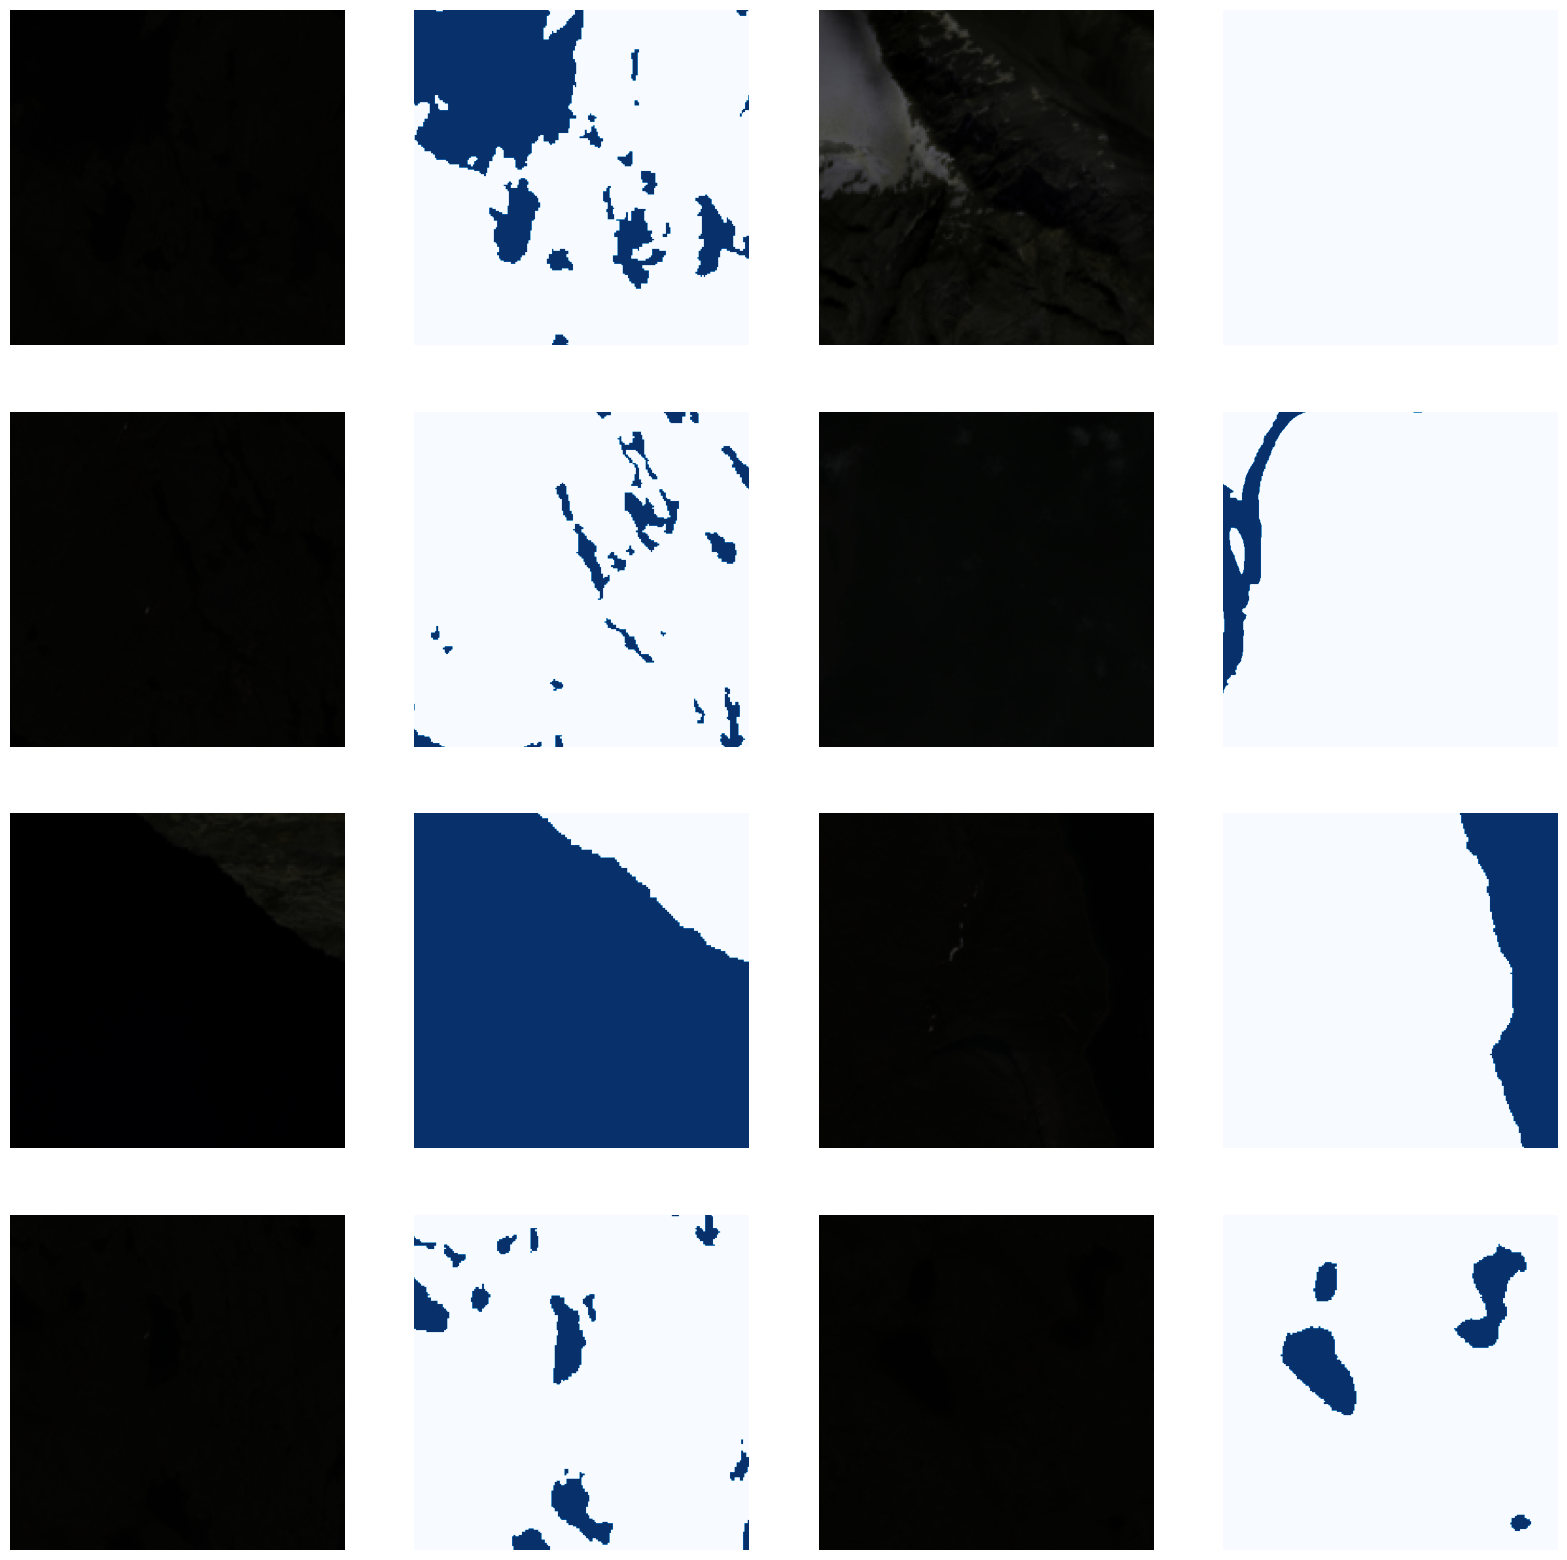

In [17]:
batch = next(iter(loader))
plot_batch(batch)

# Step 5. Normalize the merged dataset.

# Step 6. Enrich the image dataset with various spectral index maps.

In [19]:
mndwi_transform = torchgeo.transforms.indices.AppendNDWI(index_green=1, index_nir=4)
ndwi_transform = torchgeo.transforms.indices.AppendNDWI(index_green=1, index_nir=3)
ndvi_transform = torchgeo.transforms.indices.AppendNDVI(index_nir=3, index_red=2)

AttributeError: 'collections.defaultdict' object has no attribute 'shape'

In [ ]:
transformed_batch = mndwi_transform(batch)
transformed_batch['image'].shape, transformed_batch['mask'].shape

In [ ]:
tfms = torch.nn.Sequential(ndwi_transform, ndwi_transform, ndvi_transform)
transformed_batch = tfms(batch)
transformed_batch['image'].shape, transformed_batch['mask'].shape

# Step 7. Loss function and metrics
# Step 8. Training loop